In [1]:
import os
import time
import joblib
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, accuracy_score
from lightgbm import LGBMClassifier

import warnings

# OPTUNA
import optuna

/mnt/AI-DATA/placivm_tfg/PLACI_TFG/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# 2. PREPARACION DATASET
# ==========================================

TARGET_COL = "label"

df_encoded = pl.read_csv("../../DATASETS/dataSets_Reducidos/iot-23/datos_IOT_23_preparado.csv")

# Separación de características (X) y variable objetivo (y)
feature_columns = [col for col in df_encoded.columns if col != TARGET_COL]
X = df_encoded.select(feature_columns)
y_np = df_encoded[TARGET_COL].to_numpy().astype(np.int8)
X_np = X.to_numpy()

display(X.head())

indices = np.arange(X_np.shape[0])

train_full_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y_np,
)

train_idx, val_idx = train_test_split(
    train_full_idx,
    test_size=0.2,
    random_state=42,
    stratify=y_np[train_full_idx],
)

X_full_train_np = X_np[train_full_idx]
X_test_np = X_np[test_idx]
y_full_train = y_np[train_full_idx]
y_test_np = y_np[test_idx]

X_train_np = X_np[train_idx]
X_val_np = X_np[val_idx]
y_train_np = y_np[train_idx]
y_val_np = y_np[val_idx]

print(f"Entrenamiento: {len(X_train_np):,} muestras")
print(f"Validación:    {len(X_val_np):,} muestras")
print(f"Test:          {len(X_test_np):,} muestras")
print(f"Clases en test: {np.unique(y_test_np)}")
print(f"Total muestras: {len(X_np):,}")

id.orig_p,id.resp_p,proto_icmp,proto_tcp,proto_udp,duration,orig_bytes,resp_bytes,orig_pkts,resp_pkts,conn_state_OTH,conn_state_REJ,conn_state_RSTO,conn_state_RSTOS0,conn_state_RSTR,conn_state_RSTRH,conn_state_S0,conn_state_S1,conn_state_S2,conn_state_SF,conn_state_SH,conn_state_SHR
i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
51524,23,0,1,0,2.999051,0.0,0.0,3,0,0,0,0,0,0,0,1,0,0,0,0,0
56305,23,0,1,0,-1.0,-1.0,-1.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
41101,23,0,1,0,-1.0,-1.0,-1.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
60905,23,0,1,0,2.998796,0.0,0.0,3,0,0,0,0,0,0,0,1,0,0,0,0,0
44301,23,0,1,0,-1.0,-1.0,-1.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0


Entrenamiento: 745,504 muestras
Validación:    186,376 muestras
Test:          232,971 muestras
Clases en test: [0 1]
Total muestras: 1,164,851


In [6]:
# ==========================================
# 2. FASE 1: OPTUNA + 3-FOLD CV (ESTRUCTURA REAL)
# ==========================================

# Convertir -1/1 a 0/1 ANTES de entrar a Optuna
y_full_train_01 = ((y_full_train + 1) // 2).astype(np.int8)


def objective(trial):

    warnings.filterwarnings("ignore", category=UserWarning)
    
    n_estimators = trial.suggest_int("n_estimators", 50, 600, step=50)
    num_leaves = trial.suggest_int("num_leaves", 15, 255) 
    max_depth = trial.suggest_int("max_depth", 3, 12)    
    
    skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42) # Reducción a 2 folds para acelerar el proceso
    f1_scores = []
    latencies = []

    for train_idx, val_idx in skf.split(X_full_train_np, y_full_train_01):
        X_train_cv, X_val_cv = X_full_train_np[train_idx], X_full_train_np[val_idx]
        y_train_cv, y_val_cv = y_full_train_01[train_idx], y_full_train_01[val_idx]

        model = LGBMClassifier(
            n_estimators=n_estimators,
            num_leaves=num_leaves,
            max_depth=max_depth,
            learning_rate=0.1,  
            objective="binary", # Forzamos que sepa que es 0/1
            device_type="cpu",
            n_jobs=-1,          
            random_state=42,
            verbosity=-1        
        )

        model.fit(X_train_cv, y_train_cv)
        model.set_params(device_type="cpu")

        # 1. Medir Eficacia
        y_pred = model.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, y_pred, average="macro"))

        # 2. Medir Eficiencia dentro de cada fold
        subset = min(20000, len(X_val_cv))
        X_lat = X_val_cv[:subset]

        # Warm-up rápido
        _ = model.predict(X_lat[:500])

        rep_lat = []
        for _ in range(5):
            t0 = time.perf_counter()
            _ = model.predict(X_lat)
            t1 = time.perf_counter()
            rep_lat.append((t1 - t0) / len(X_lat) * 1000)

        latencies.append(float(np.mean(rep_lat)))

    avg_lat = float(np.mean(latencies))
    avg_f1 = float(np.mean(f1_scores))
    trial.set_user_attr("f1_std", float(np.std(f1_scores)))

    return avg_f1, avg_lat

# Ejecución del estudio
study = optuna.create_study(directions=["maximize", "minimize"], study_name="lgbm_iot_ids_optimization")
print("🚀 Iniciando barrido multiobjetivo con LightGBM...")
study.optimize(objective, n_trials=50)

# ==========================================
# 3. EXPORTACIÓN Y VISUALIZACIÓN PARETO
# ==========================================

pareto_ids = {t.number for t in study.best_trials}
trials_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            "n_estimators": t.params["n_estimators"],
            "num_leaves": t.params["num_leaves"],
            "max_depth": t.params["max_depth"],
            "f1_macro": t.values[0],
            "f1_std": t.user_attrs["f1_std"],
            "latency_ms": t.values[1],
            "is_pareto": t.number in pareto_ids
        })

df_results = pl.DataFrame(trials_data)
df_results.write_csv("lgbm_iot_trials_results_cv.csv")

[I 2026-04-20 19:51:25,901] A new study created in memory with name: lgbm_iot_ids_optimization


🚀 Iniciando barrido multiobjetivo con LightGBM...


[I 2026-04-20 19:52:35,916] Trial 0 finished with values: [0.9998209969312184, 0.0011881608749536097] and parameters: {'n_estimators': 550, 'num_leaves': 184, 'max_depth': 11}.
[I 2026-04-20 19:52:38,633] Trial 1 finished with values: [0.9997643027886385, 0.00014113993998762455] and parameters: {'n_estimators': 100, 'num_leaves': 231, 'max_depth': 7}.
[I 2026-04-20 19:52:44,259] Trial 2 finished with values: [0.9799179830934268, 0.00021979525999995533] and parameters: {'n_estimators': 150, 'num_leaves': 194, 'max_depth': 10}.
[I 2026-04-20 19:53:00,841] Trial 3 finished with values: [0.9998221086629069, 0.0010973474649654236] and parameters: {'n_estimators': 500, 'num_leaves': 130, 'max_depth': 12}.
[I 2026-04-20 19:53:04,139] Trial 4 finished with values: [0.9848956235040238, 0.00019493697505822637] and parameters: {'n_estimators': 200, 'num_leaves': 69, 'max_depth': 5}.
[I 2026-04-20 19:53:05,208] Trial 5 finished with values: [0.9997576190660831, 0.00011414861002776889] and paramete

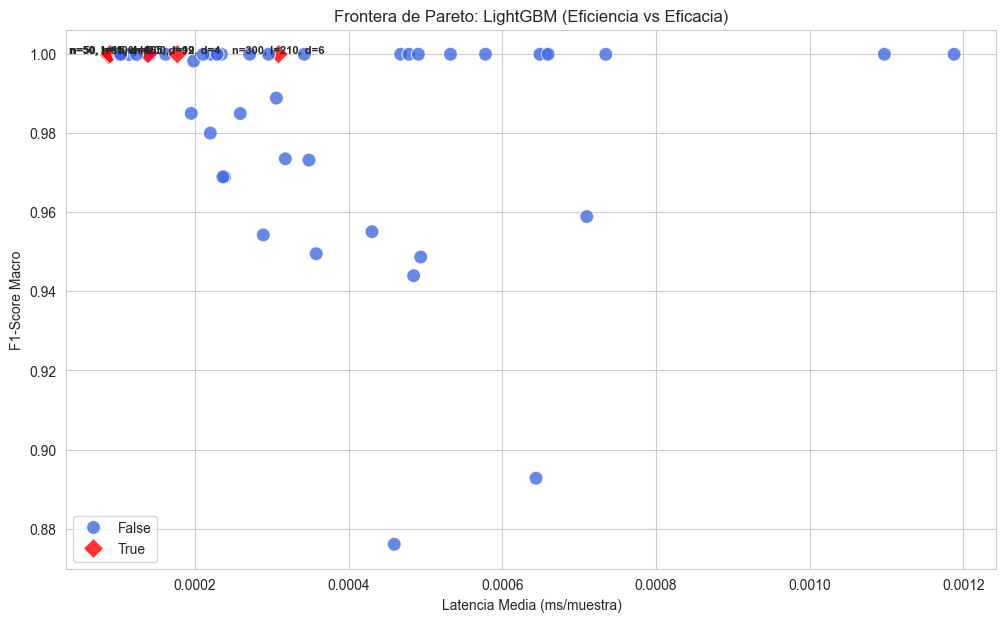

In [11]:
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.scatterplot(
    x=df_results["latency_ms"].to_numpy(),
    y=df_results["f1_macro"].to_numpy(),
    hue=df_results["is_pareto"].to_numpy(),
    palette={True: "red", False: "royalblue"},
    style=df_results["is_pareto"].to_numpy(),
    markers={True: "D", False: "o"}, s=100, alpha=0.8
)

# Anotación de puntos Pareto
pareto_points = df_results.filter(pl.col("is_pareto") == True)
for row in pareto_points.iter_rows(named=True):
    plt.text(row["latency_ms"], row["f1_macro"] + 0.0005, 
             f"n={int(row['n_estimators'])}, l={int(row['num_leaves'])}, d={int(row['max_depth'])}", 
             fontsize=8, fontweight='bold', ha='center')

plt.title("Frontera de Pareto: LightGBM (Eficiencia vs Eficacia)")
plt.xlabel("Latencia Media (ms/muestra)")
plt.ylabel("F1-Score Macro")
plt.show()

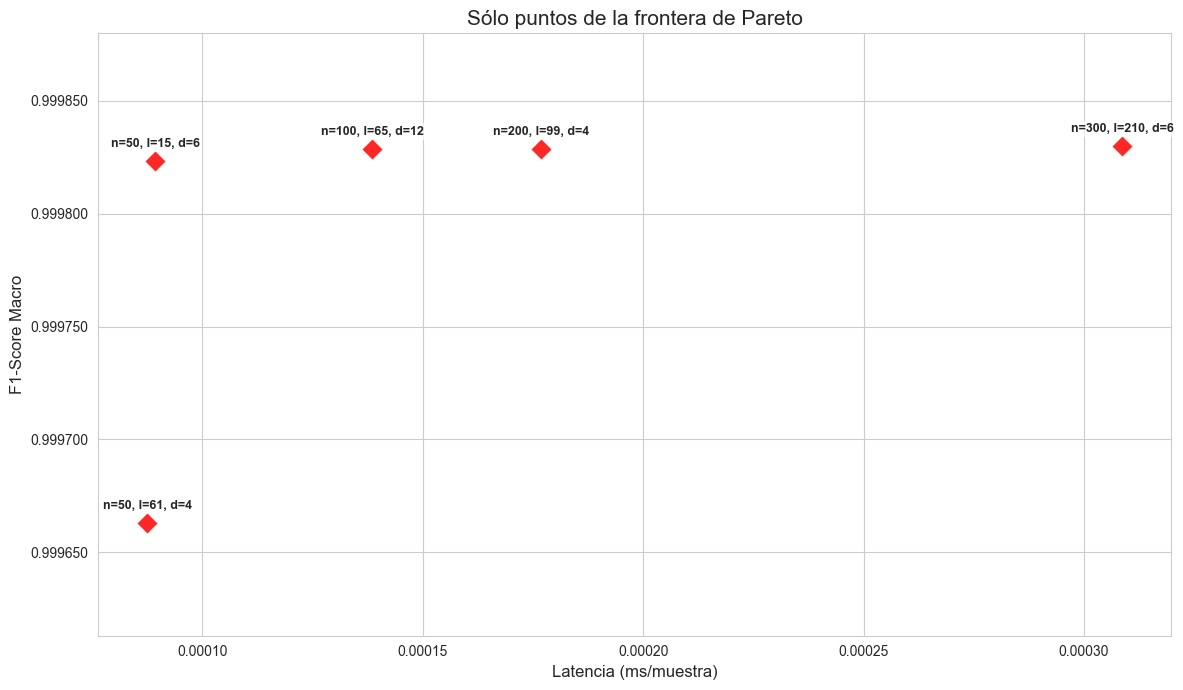

n_estimators,num_leaves,max_depth,f1_macro,f1_std,latency_ms,is_pareto
i64,i64,i64,f64,f64,f64,bool
50,61,4,0.999663,0.000041,0.000087,true
50,15,6,0.999823,0.000061,0.000089,true
100,65,12,0.999829,0.000062,0.000138,true
200,99,4,0.999829,0.000067,0.000177,true
300,210,6,0.99983,0.000068,0.000309,true


In [12]:
# representamos únicamente los puntos que forman la frontera de Pareto

from matplotlib.ticker import FormatStrFormatter

# 1. cargamos los resultados y filtramos
df = pl.read_csv("lgbm_iot_trials_results_cv.csv")
pareto = (
    df
    .filter(pl.col("is_pareto") == True)
    .sort("latency_ms")
)

# 2. estilo
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
ax = plt.gca()

# 3. dibujamos sólo los puntos de Pareto
sns.scatterplot(
    x=pareto["latency_ms"].to_numpy(),
    y=pareto["f1_macro"].to_numpy(),
    color="red",
    marker="D",
    s=120,
    alpha=0.85,
    ax=ax
)

# Evitamos el formato raro del eje Y cuando los F1 están muy cerca de 1.0
ax.ticklabel_format(style='plain', axis='y', useOffset=False)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.6f'))

# Añadimos un pequeño margen vertical para que respiren los puntos
y_vals = pareto["f1_macro"].to_numpy()
if len(y_vals) > 0:
    y_min = float(y_vals.min())
    y_max = float(y_vals.max())
    margin = max((y_max - y_min) * 0.2, 0.00005)
    ax.set_ylim(y_min - margin, y_max + margin)

# 4. anotamos cada punto pegado a su marca roja
for row in pareto.iter_rows(named=True):
    ax.annotate(
        f"n={int(row['n_estimators'])}, l={int(row['num_leaves'])}, d={int(row['max_depth'])}",
        xy=(row["latency_ms"], row["f1_macro"]),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5)
    )

# 5. etiquetas
plt.title("Sólo puntos de la frontera de Pareto", fontsize=15)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Macro", fontsize=12)
plt.tight_layout()
plt.show()

# Mostramos los puntos de Pareto
display(pareto)

In [13]:
# ==========================================
# 4. FASE 3: EVALUACIÓN FINAL EN TEST
# ==========================================

# Aquí deberás ajustar estos candidatos con los que veas en ROJO en tu gráfica
candidatos = [
    {"n": 50, "l": 15, "d": 6,  "nombre": "Candidato 1"},
    {"n": 100, "l": 65, "d": 12,  "nombre": "Candidato 2"},
    {"n": 200, "l": 99, "d": 4, "nombre": "Candidato 3"},
    {"n": 50, "l": 61, "d": 4, "nombre": "Candidato 4"},
    {"n": 300, "l": 210, "d": 6, "nombre": "Candidato 5"},
]

resultados_finales = []

print("\n--- EVALUACIÓN FINAL SOBRE TEST (COHERENTE) ---")
for c in candidatos:
    model_final = LGBMClassifier(
        n_estimators=c["n"],
        num_leaves=c["l"],
        max_depth=c["d"],
        learning_rate=0.1, # Coherencia con la Fase 1
        device_type="gpu",
        n_jobs=-1,
        random_state=42,
        verbosity=-1
    )
    
    model_final.fit(X_full_train_np, y_full_train_01)
    model_final.set_params(device_type="cpu")
    
    # Medición de latencia real en Test (5 pasadas)
    t_start = time.perf_counter()
    y_test_pred = model_final.predict(X_test_np)
    t_end = time.perf_counter()
    
    resultados_finales.append({
        "Perfil": c["nombre"],
        "n_est": c["n"],
        "leaves": c["l"],
        "depth": c["d"],
        "F1_Test": f1_score(y_test_np, y_test_pred, average="macro"),
        "Acc_Test": accuracy_score(y_test_np, y_test_pred),
        "Latencia_ms": ((t_end - t_start) / len(X_test_np)) * 1000
    })

df_final = pl.DataFrame(resultados_finales)
print("\n", df_final)


--- EVALUACIÓN FINAL SOBRE TEST (COHERENTE) ---

 shape: (5, 7)
┌─────────────┬───────┬────────┬───────┬──────────┬──────────┬─────────────┐
│ Perfil      ┆ n_est ┆ leaves ┆ depth ┆ F1_Test  ┆ Acc_Test ┆ Latencia_ms │
│ ---         ┆ ---   ┆ ---    ┆ ---   ┆ ---      ┆ ---      ┆ ---         │
│ str         ┆ i64   ┆ i64    ┆ i64   ┆ f64      ┆ f64      ┆ f64         │
╞═════════════╪═══════╪════════╪═══════╪══════════╪══════════╪═════════════╡
│ Candidato 1 ┆ 50    ┆ 15     ┆ 6     ┆ 0.999813 ┆ 0.99982  ┆ 0.000057    │
│ Candidato 2 ┆ 100   ┆ 65     ┆ 12    ┆ 0.999831 ┆ 0.999837 ┆ 0.000099    │
│ Candidato 3 ┆ 200   ┆ 99     ┆ 4     ┆ 0.999795 ┆ 0.999803 ┆ 0.00017     │
│ Candidato 4 ┆ 50    ┆ 61     ┆ 4     ┆ 0.999631 ┆ 0.999644 ┆ 0.000058    │
│ Candidato 5 ┆ 300   ┆ 210    ┆ 6     ┆ 0.881924 ┆ 0.882891 ┆ 0.000261    │
└─────────────┴───────┴────────┴───────┴──────────┴──────────┴─────────────┘
